# Quantium Retail Analytics — Chip Category Analysis
## Notebook 3: Experimentation & Uplift Testing — Trial vs Control Stores

**Analyst:** Amay  
**Date:** April 2026  
**Input data:** quantium_clean_merged.csv (cleaned output from Notebook 1)

### Context
Julia (Category Manager) trialled a new chip layout in stores 77, 86 and 88.
This notebook identifies the best control store for each trial store,
compares performance during the trial period, and provides a data-driven
recommendation on whether the new layout should be rolled out to all stores.

### Trial stores
| Store | Trial period |
|---|---|
| 77 | Feb 2019 – Apr 2019 |
| 86 | Feb 2019 – Apr 2019 |
| 88 | Feb 2019 – Apr 2019 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlesize']    = 13
sns.set_palette("muted")

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
from google.colab import files

print("Upload quantium_clean_merged.csv:")
uploaded = files.upload()

merged = pd.read_csv('quantium_clean_merged.csv', parse_dates=['DATE'])

print(f"\n✓ Data loaded: {merged.shape[0]:,} rows × {merged.shape[1]} columns")
print(f"  Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"  Stores:     {merged['STORE_NBR'].nunique()}")
print(f"  Columns:    {merged.columns.tolist()}")

Upload quantium_clean_merged.csv:


Saving quantium_clean_merged.csv to quantium_clean_merged.csv

✓ Data loaded: 246,739 rows × 13 columns
  Date range: 2018-07-01 → 2019-06-30
  Stores:     271
  Columns:    ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'UNIT_PRICE', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']


In [4]:
# Define trial stores and trial period
TRIAL_STORES  = [77, 86, 88]
TRIAL_START   = pd.Timestamp('2019-02-01')
TRIAL_END     = pd.Timestamp('2019-04-30')
PRE_TRIAL_START = pd.Timestamp('2018-07-01')
PRE_TRIAL_END   = pd.Timestamp('2019-01-31')

print(f"Trial stores:      {TRIAL_STORES}")
print(f"Pre-trial period:  {PRE_TRIAL_START.date()} → {PRE_TRIAL_END.date()}")
print(f"Trial period:      {TRIAL_START.date()} → {TRIAL_END.date()}")

# Confirm trial stores exist in data
for store in TRIAL_STORES:
    count = merged[merged['STORE_NBR'] == store].shape[0]
    print(f"  Store {store}: {count:,} transactions")

Trial stores:      [77, 86, 88]
Pre-trial period:  2018-07-01 → 2019-01-31
Trial period:      2019-02-01 → 2019-04-30
  Store 77: 529 transactions
  Store 86: 1,439 transactions
  Store 88: 1,786 transactions


In [5]:
# Calculate monthly metrics per store

# Add year-month column for grouping
merged['YEARMONTH'] = merged['DATE'].dt.to_period('M')

# Monthly metrics per store
monthly = (merged
    .groupby(['STORE_NBR', 'YEARMONTH'])
    .agg(
        total_sales      = ('TOT_SALES',      'sum'),
        num_customers    = ('LYLTY_CARD_NBR', 'nunique'),
        num_txns         = ('TXN_ID',         'nunique'),
    )
    .reset_index()
)

monthly['avg_txns_per_customer'] = (
    monthly['num_txns'] / monthly['num_customers']).round(4)

monthly['YEARMONTH_DT'] = monthly['YEARMONTH'].dt.to_timestamp()

print(f"✓ Monthly metrics calculated")
print(f"  Stores:        {monthly['STORE_NBR'].nunique()}")
print(f"  Month-store rows: {len(monthly):,}")
print("\nSample — Store 77:")
display(monthly[monthly['STORE_NBR'] == 77].head(8))

✓ Monthly metrics calculated
  Stores:        271
  Month-store rows: 3,165

Sample — Store 77:


,STORE_NBR,YEARMONTH,total_sales,num_customers,num_txns,avg_txns_per_customer,YEARMONTH_DT
880,77,2018-07,268.4,47,51,1.0851,2018-07-01
881,77,2018-08,247.5,46,46,1.0000,2018-08-01
882,77,2018-09,216.8,40,42,1.0500,2018-09-01
883,77,2018-10,194.3,36,37,1.0278,2018-10-01
884,77,2018-11,224.9,39,42,1.0769,2018-11-01
885,77,2018-12,255.2,43,44,1.0233,2018-12-01
886,77,2019-01,188.4,31,35,1.1290,2019-01-01
887,77,2019-02,211.6,40,40,1.0000,2019-02-01


In [6]:
# Split pre-trial and trial periods

pre_trial = monthly[
    (monthly['YEARMONTH_DT'] >= PRE_TRIAL_START) &
    (monthly['YEARMONTH_DT'] <= PRE_TRIAL_END)
].copy()

trial_period = monthly[
    (monthly['YEARMONTH_DT'] >= TRIAL_START) &
    (monthly['YEARMONTH_DT'] <= TRIAL_END)
].copy()

print(f"Pre-trial months per store: {pre_trial['YEARMONTH'].nunique()}")
print(f"Trial months per store:     {trial_period['YEARMONTH'].nunique()}")

# Exclude trial stores from control pool
control_pool = monthly[
    ~monthly['STORE_NBR'].isin(TRIAL_STORES)
].copy()

print(f"\nStores available as controls: {control_pool['STORE_NBR'].nunique()}")

Pre-trial months per store: 7
Trial months per store:     3

Stores available as controls: 268


In [8]:
# Control store function
def select_control_store(trial_store_nbr, metric='total_sales', top_n=5):
    """
    For a given trial store, find the best matching control store
    using a combined score of:
      - Pearson correlation of monthly metric during pre-trial period
      - Magnitude distance (normalised) of monthly metric during pre-trial period
    Returns a ranked dataframe of top_n candidate control stores.
    """
    # Pre-trial data for the trial store
    trial_data = (pre_trial[pre_trial['STORE_NBR'] == trial_store_nbr]
                  .set_index('YEARMONTH')[metric])

    results = []

    for store in control_pool['STORE_NBR'].unique():
        ctrl_data = (pre_trial[pre_trial['STORE_NBR'] == store]
                     .set_index('YEARMONTH')[metric])

        # Align on common months
        common = trial_data.index.intersection(ctrl_data.index)
        if len(common) < 4:
            continue

        t = trial_data.loc[common].values
        c = ctrl_data.loc[common].values

        # Pearson correlation
        corr, _ = stats.pearsonr(t, c)

        # Magnitude distance score
        distances = np.abs(t - c)
        obs_dist  = distances.mean()
        min_dist  = 0
        max_dist  = distances.max() if distances.max() > 0 else 1
        mag_score = 1 - (obs_dist - min_dist) / (max_dist - min_dist)

        # Combined score — equal weight
        combined = (corr + mag_score) / 2

        results.append({
            'control_store'  : store,
            'correlation'    : round(corr, 4),
            'magnitude_score': round(mag_score, 4),
            'combined_score' : round(combined, 4),
        })

    ranked = (pd.DataFrame(results)
              .sort_values('combined_score', ascending=False)
              .reset_index(drop=True))

    return ranked.head(top_n)


print("✓ Control store selection function defined")

✓ Control store selection function defined


In [9]:
#  Select control stores for all 3 trial stores
metrics_to_use = 'total_sales'

print("=" * 55)
for store in TRIAL_STORES:
    print(f"\nTop 5 control candidates for Trial Store {store}:")
    result = select_control_store(store, metric=metrics_to_use)
    display(result)
    print("─" * 55)


Top 5 control candidates for Trial Store 77:


,control_store,correlation,magnitude_score,combined_score
0,233,0.9736,0.5417,0.7576
1,50,0.8977,0.4301,0.6639
2,167,0.6547,0.4651,0.5599
3,53,0.6365,0.4692,0.5529
4,188,0.5425,0.5155,0.5290


───────────────────────────────────────────────────────

Top 5 control candidates for Trial Store 86:


,control_store,correlation,magnitude_score,combined_score
0,155,0.8695,0.6220,0.7458
1,114,0.7509,0.5799,0.6654
2,106,0.6821,0.6317,0.6569
3,269,0.7474,0.5179,0.6327
4,138,0.7961,0.4485,0.6223


───────────────────────────────────────────────────────

Top 5 control candidates for Trial Store 88:


,control_store,correlation,magnitude_score,combined_score
0,91,0.9120,0.0901,0.5010
1,159,0.9388,0.0515,0.4952
2,7,0.6988,0.2701,0.4845
3,204,0.8720,0.0619,0.4669
4,79,0.7720,0.1528,0.4624


───────────────────────────────────────────────────────


## Phase 1 & 2 Summary — Monthly Metrics & Control Selection


| Trial store | Best control store | Correlation | Combined score |
|---|---|---|---|
| 77 | 233 | 0.9736 | 0.7576 |
| 86 | 155 | 0.8695 | 0.7458 |
| 88 | 91 | 0.9120 | 0.5010 |

**Note:** Store 88 control match is weaker on magnitude — interpret with caution.

In [10]:
# Asigned Control Stores
# Confirmed control store assignments
control_map = {
    77: 233,
    86: 155,
    88: 91
}

print("Control store assignments:")
for trial, control in control_map.items():
    print(f"  Trial Store {trial} → Control Store {control}")

Control store assignments:
  Trial Store 77 → Control Store 233
  Trial Store 86 → Control Store 155
  Trial Store 88 → Control Store 91


In [11]:
# Pre-trial trend visualisation function

def plot_pretrial_trends(trial_store, control_store, metric='total_sales',
                          metric_label='Total Sales ($)'):
    """
    Plot pre-trial monthly trends for a trial/control pair
    to visually confirm they are well matched.
    """
    t = monthly[monthly['STORE_NBR'] == trial_store].sort_values('YEARMONTH_DT')
    c = monthly[monthly['STORE_NBR'] == control_store].sort_values('YEARMONTH_DT')

    # Pre-trial only
    t_pre = t[t['YEARMONTH_DT'] <= PRE_TRIAL_END]
    c_pre = c[c['YEARMONTH_DT'] <= PRE_TRIAL_END]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(t_pre['YEARMONTH_DT'], t_pre[metric],
            marker='o', linewidth=2, label=f'Trial Store {trial_store}',
            color='#C44E52')
    ax.plot(c_pre['YEARMONTH_DT'], c_pre[metric],
            marker='s', linewidth=2, label=f'Control Store {control_store}',
            color='#4C72B0', linestyle='--')

    ax.set_title(f'Pre-trial trend — Store {trial_store} vs Store {control_store}\n{metric_label}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel(metric_label)
    ax.legend(framealpha=0.9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'
                                 if 'sales' in metric.lower() else f'{x:.2f}'))

    plt.tight_layout()
    fname = f'pretrial_trend_store{trial_store}_vs_{control_store}_{metric}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")


print("✓ Pre-trial trend function defined")

✓ Pre-trial trend function defined


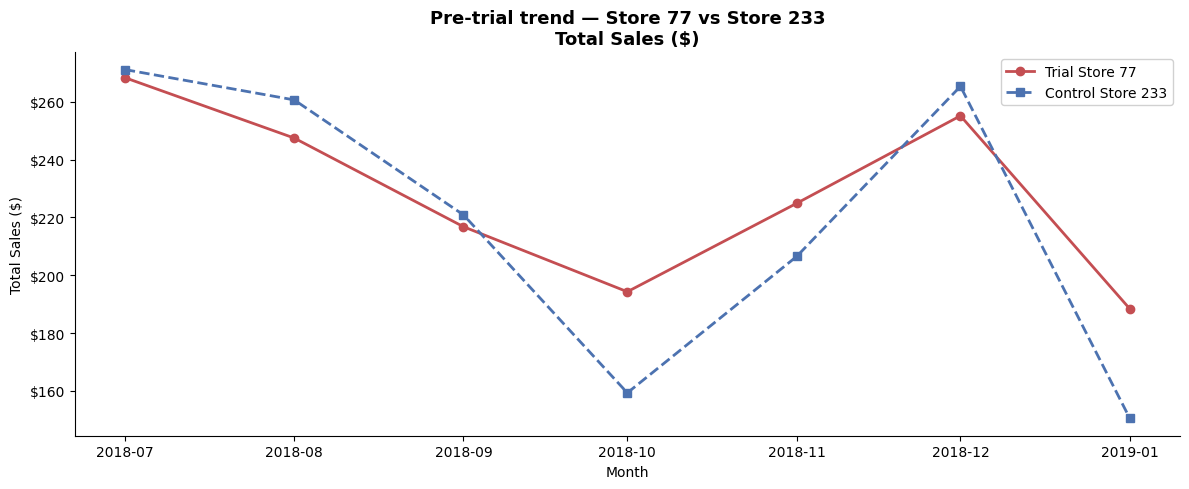

✓ Saved: pretrial_trend_store77_vs_233_total_sales.png


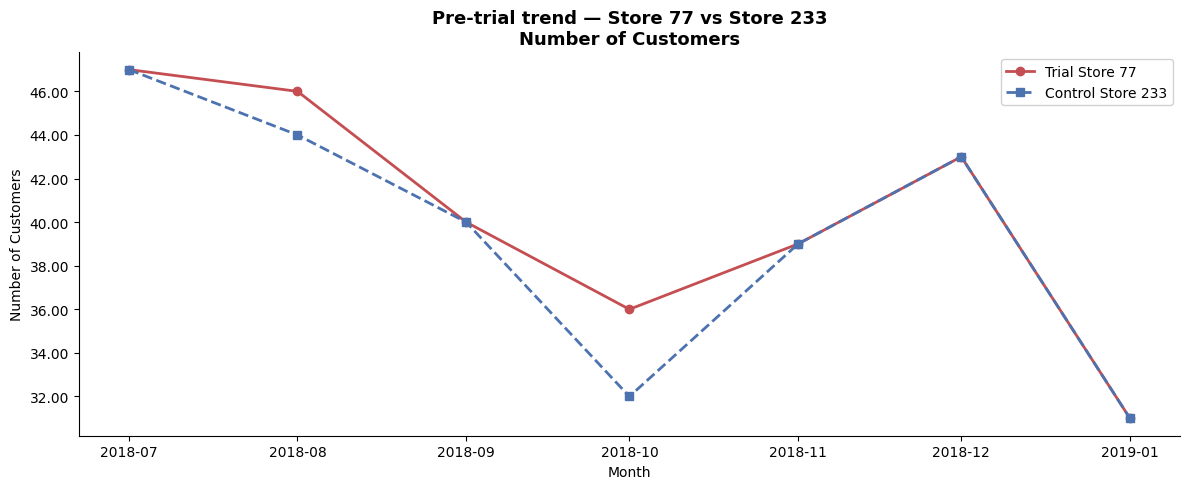

✓ Saved: pretrial_trend_store77_vs_233_num_customers.png


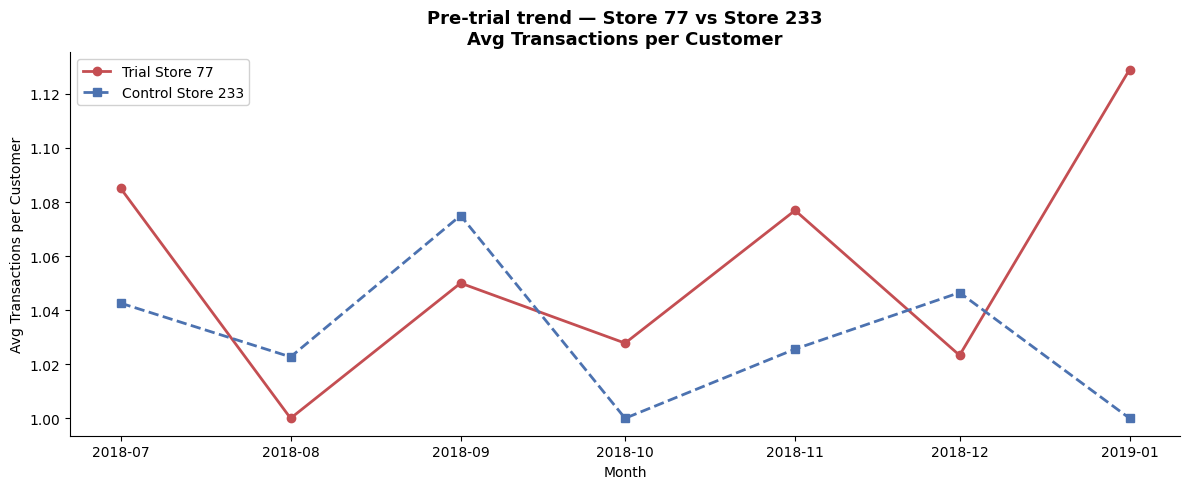

✓ Saved: pretrial_trend_store77_vs_233_avg_txns_per_customer.png


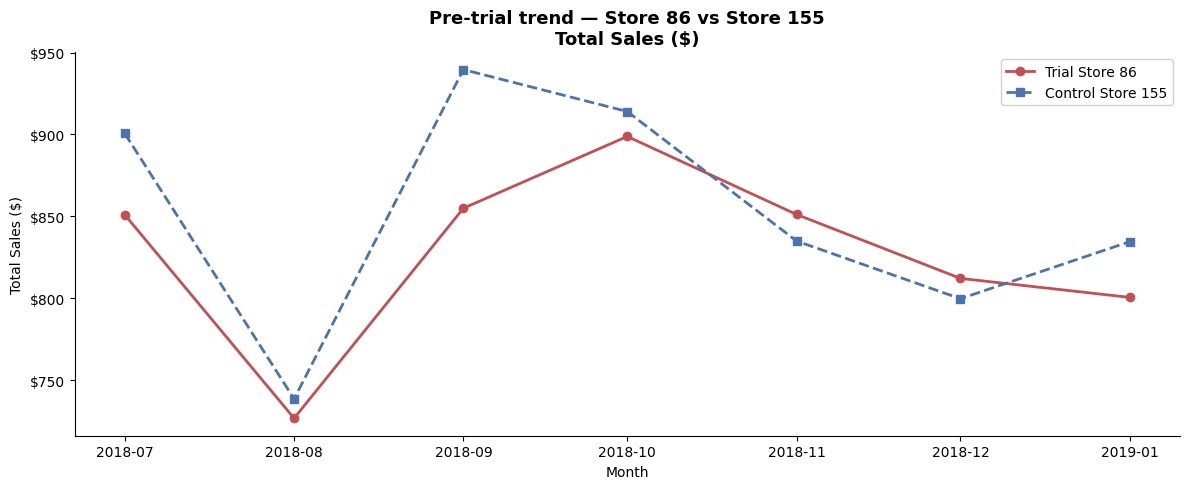

✓ Saved: pretrial_trend_store86_vs_155_total_sales.png


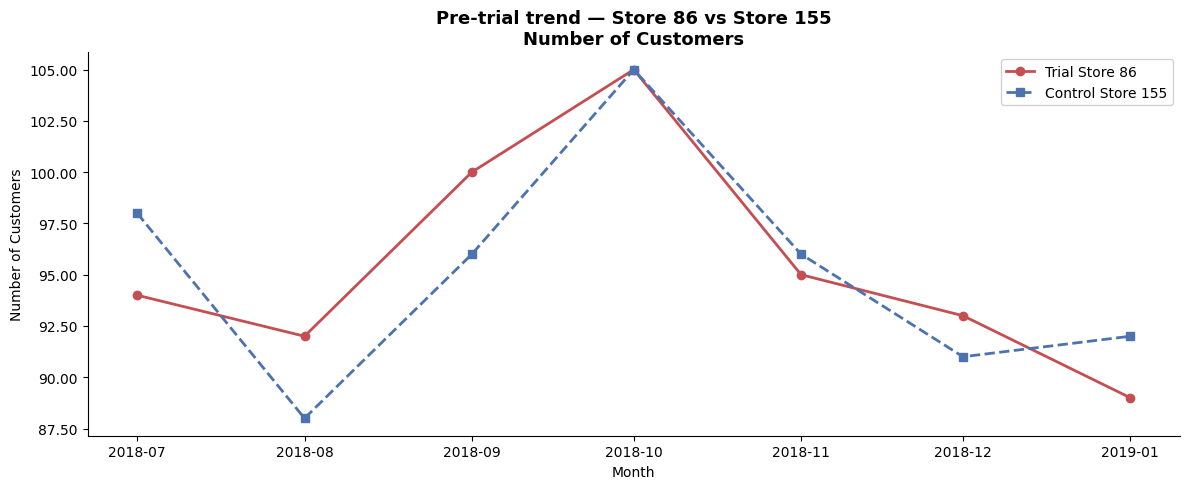

✓ Saved: pretrial_trend_store86_vs_155_num_customers.png


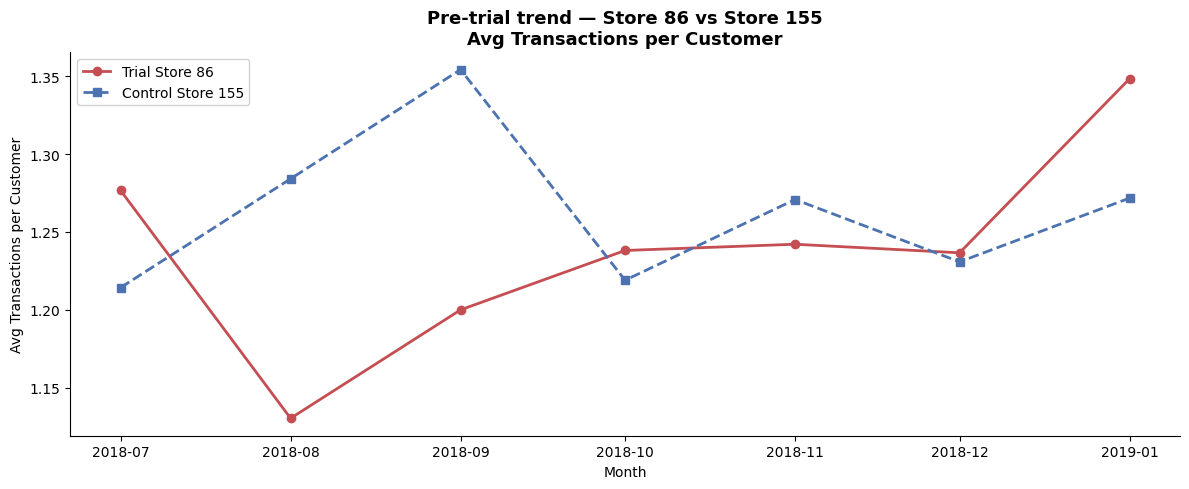

✓ Saved: pretrial_trend_store86_vs_155_avg_txns_per_customer.png


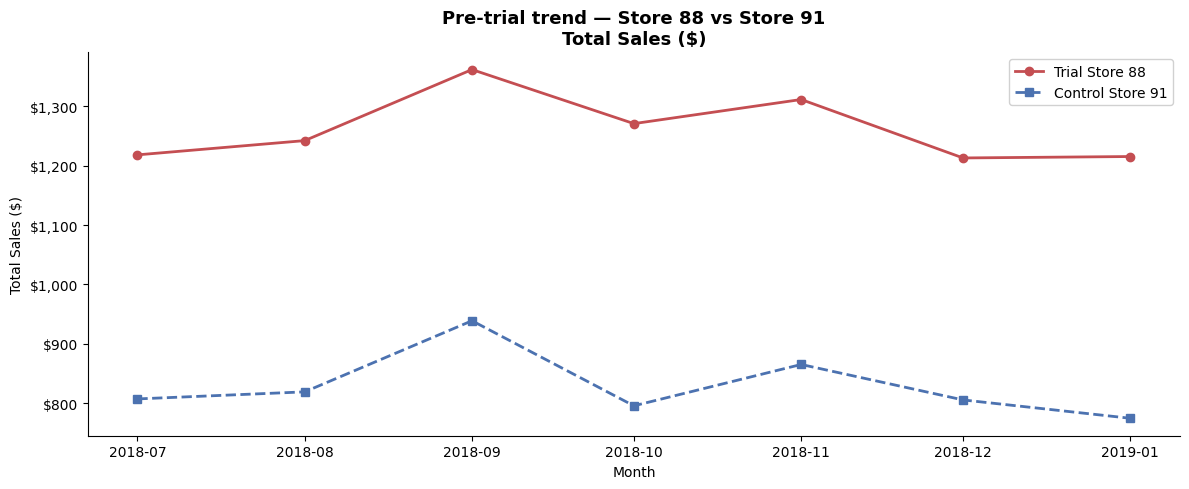

✓ Saved: pretrial_trend_store88_vs_91_total_sales.png


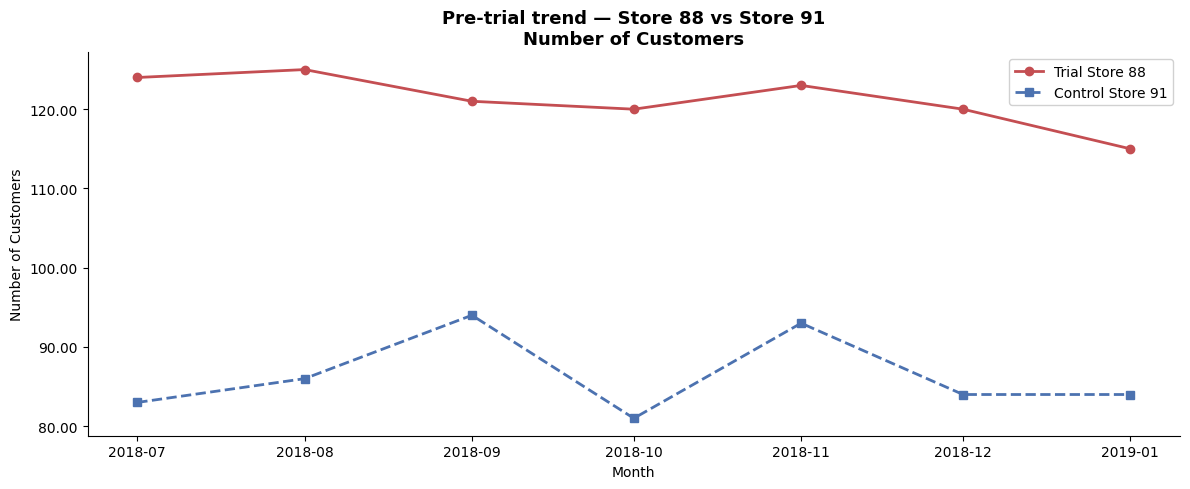

✓ Saved: pretrial_trend_store88_vs_91_num_customers.png


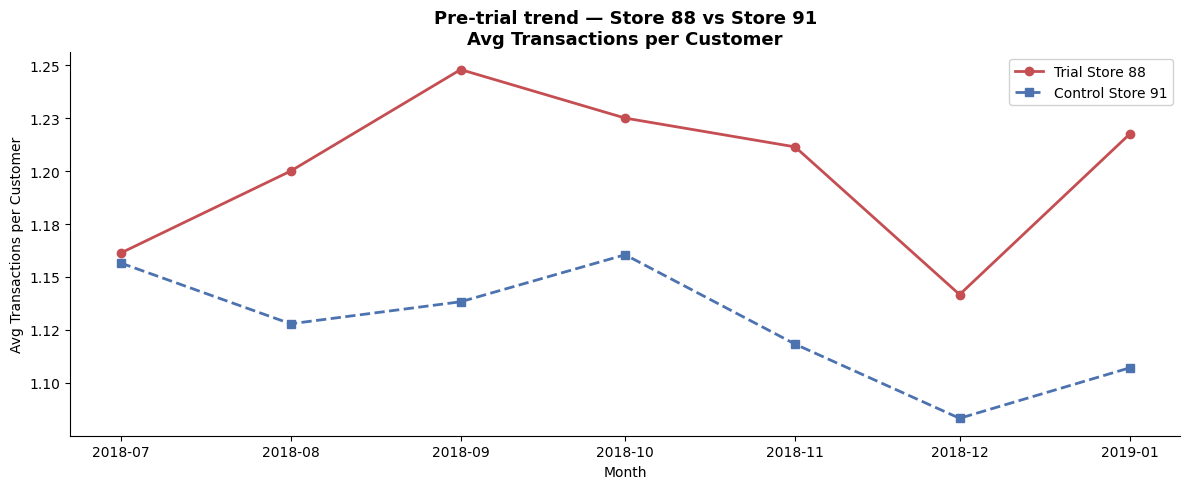

✓ Saved: pretrial_trend_store88_vs_91_avg_txns_per_customer.png


In [12]:
# Plot pre-trial trends for all 3 pairs

for trial, control in control_map.items():
    plot_pretrial_trends(trial, control,
                         metric='total_sales',
                         metric_label='Total Sales ($)')
    plot_pretrial_trends(trial, control,
                         metric='num_customers',
                         metric_label='Number of Customers')
    plot_pretrial_trends(trial, control,
                         metric='avg_txns_per_customer',
                         metric_label='Avg Transactions per Customer')

In [13]:
# Full period comparison function (pre-trial + trial)
def plot_full_comparison(trial_store, control_store, metric='total_sales',
                          metric_label='Total Sales ($)'):
    """
    Plot the full year for trial vs control, with a shaded trial period
    to clearly show where the trial started and what happened.
    """
    t = monthly[monthly['STORE_NBR'] == trial_store].sort_values('YEARMONTH_DT')
    c = monthly[monthly['STORE_NBR'] == control_store].sort_values('YEARMONTH_DT')

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(t['YEARMONTH_DT'], t[metric],
            marker='o', linewidth=2.5,
            label=f'Trial Store {trial_store}', color='#C44E52')
    ax.plot(c['YEARMONTH_DT'], c[metric],
            marker='s', linewidth=2.5,
            label=f'Control Store {control_store}',
            color='#4C72B0', linestyle='--')

    # Shade trial period
    ax.axvspan(TRIAL_START, TRIAL_END, alpha=0.12, color='orange',
               label='Trial period (Feb–Apr 2019)')
    ax.axvline(TRIAL_START, color='orange', linewidth=1, linestyle=':')
    ax.axvline(TRIAL_END,   color='orange', linewidth=1, linestyle=':')

    ax.set_title(f'Full period — Store {trial_store} vs Store {control_store}\n{metric_label}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel(metric_label)
    ax.legend(framealpha=0.9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'
                                 if 'sales' in metric.lower() else f'{x:.2f}'))

    plt.tight_layout()
    fname = f'fullperiod_store{trial_store}_vs_{control_store}_{metric}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")


print("✓ Full period comparison function defined")

✓ Full period comparison function defined


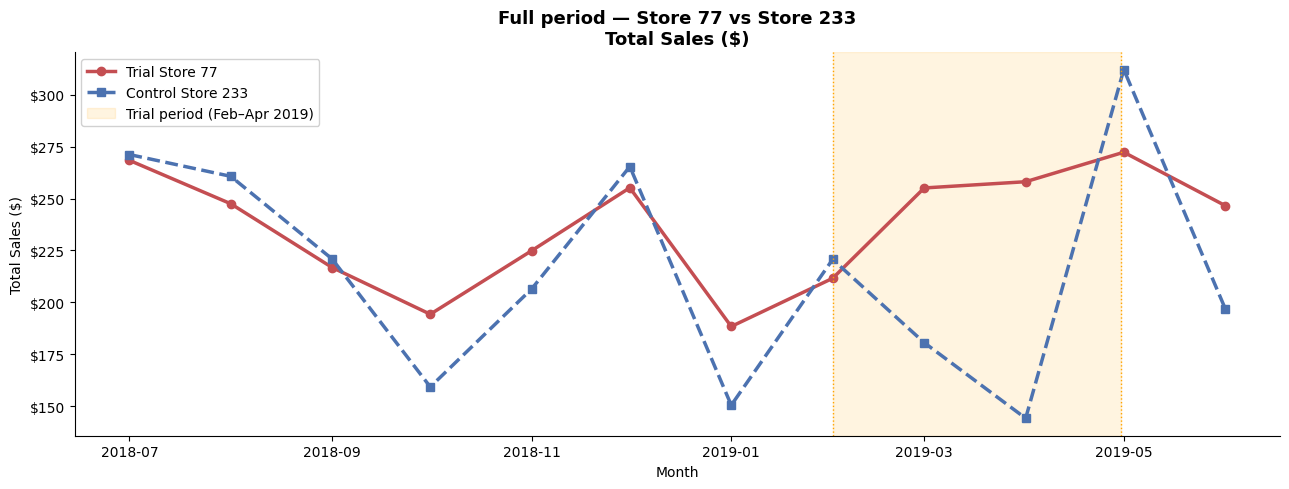

✓ Saved: fullperiod_store77_vs_233_total_sales.png


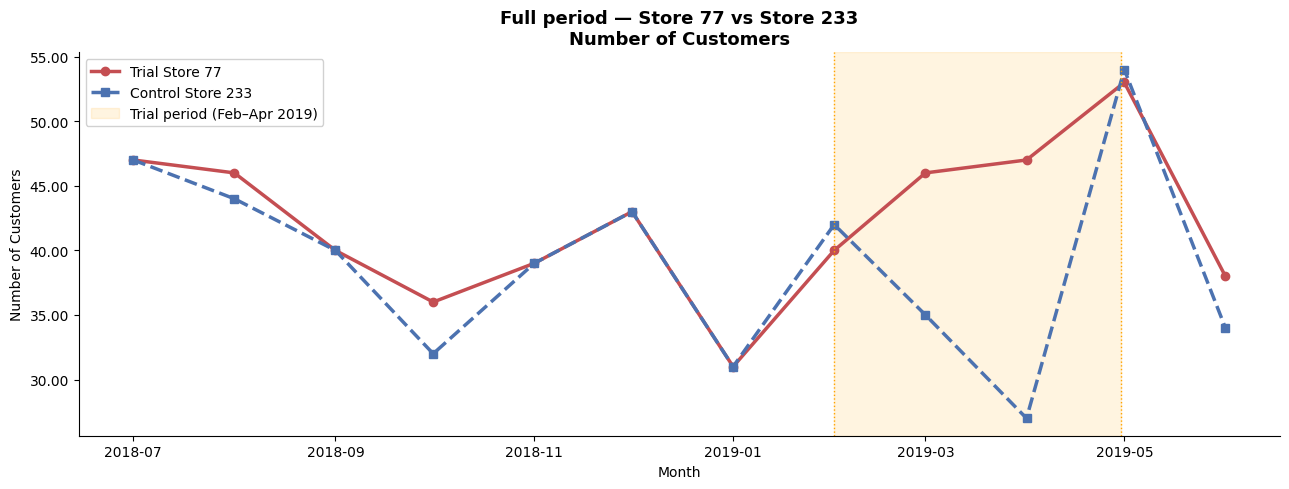

✓ Saved: fullperiod_store77_vs_233_num_customers.png


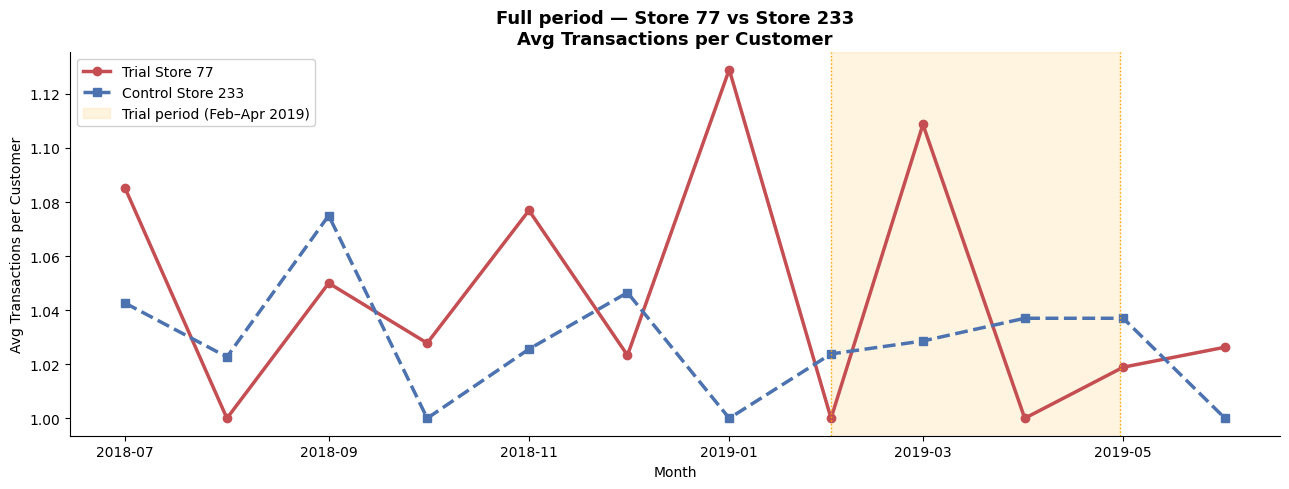

✓ Saved: fullperiod_store77_vs_233_avg_txns_per_customer.png


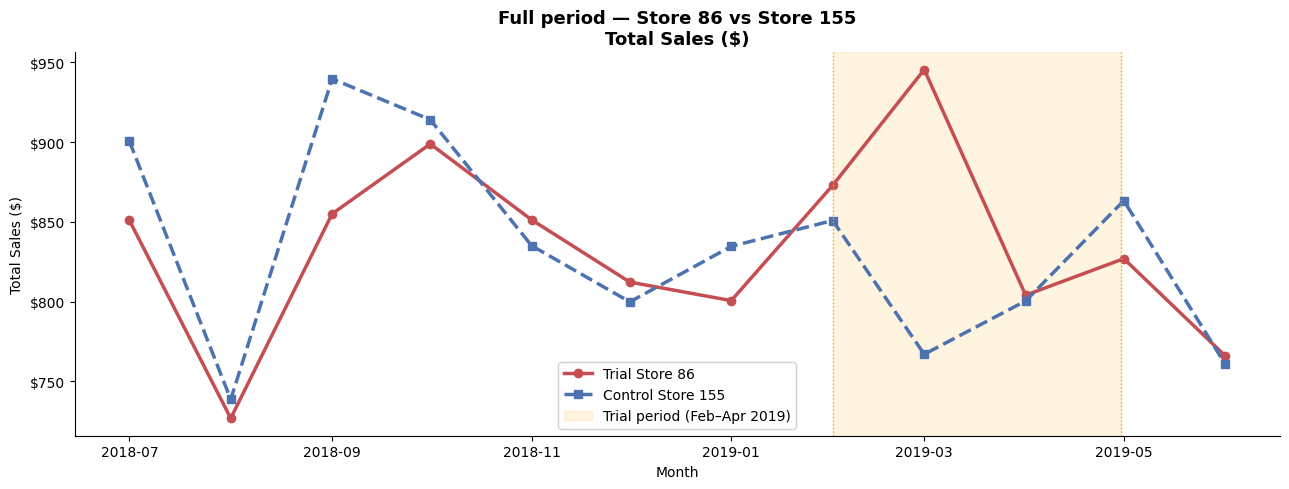

✓ Saved: fullperiod_store86_vs_155_total_sales.png


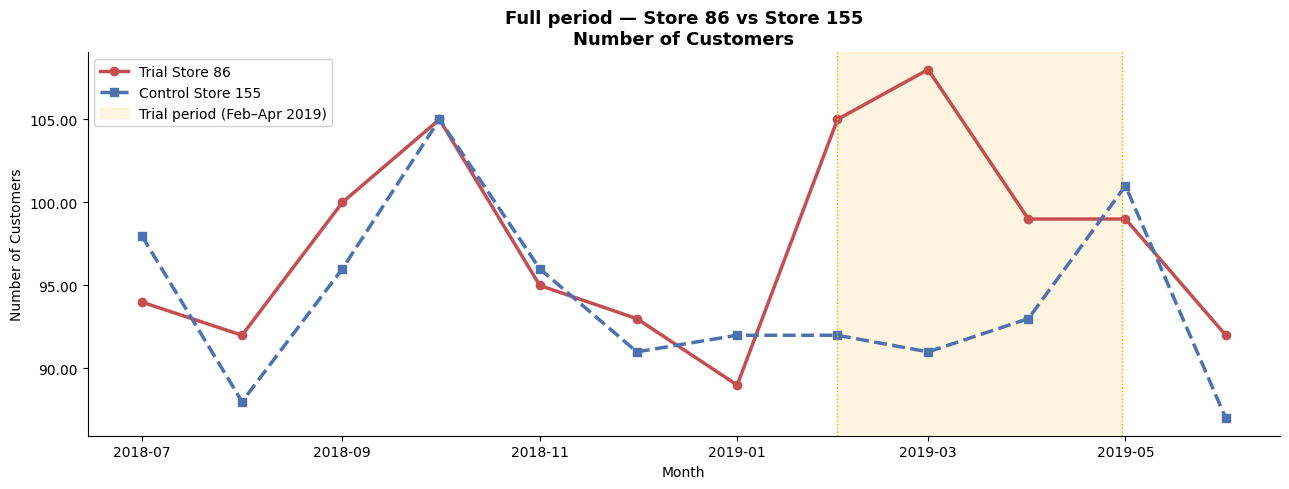

✓ Saved: fullperiod_store86_vs_155_num_customers.png


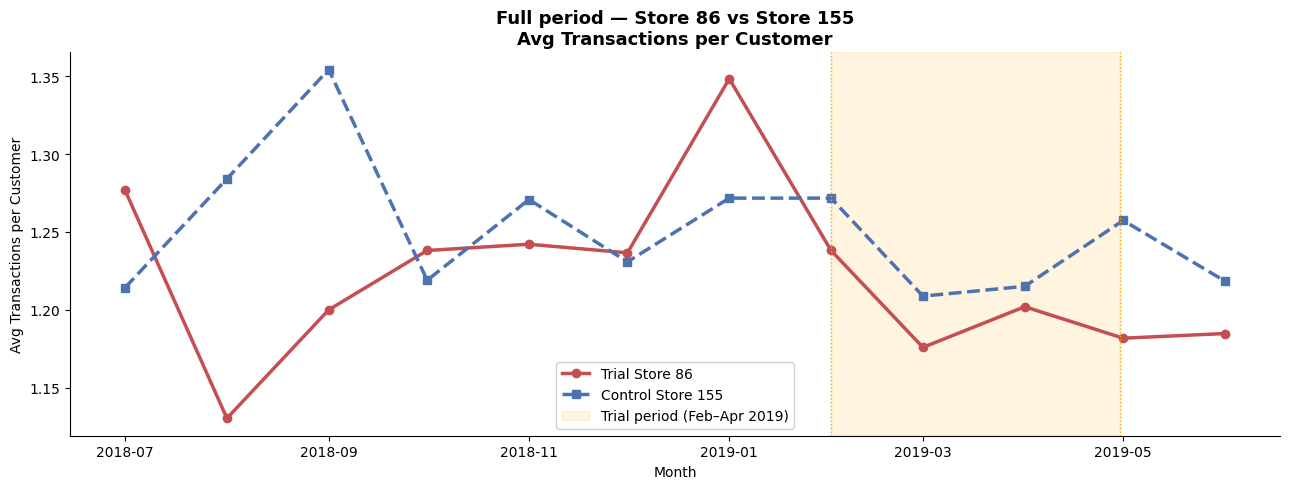

✓ Saved: fullperiod_store86_vs_155_avg_txns_per_customer.png


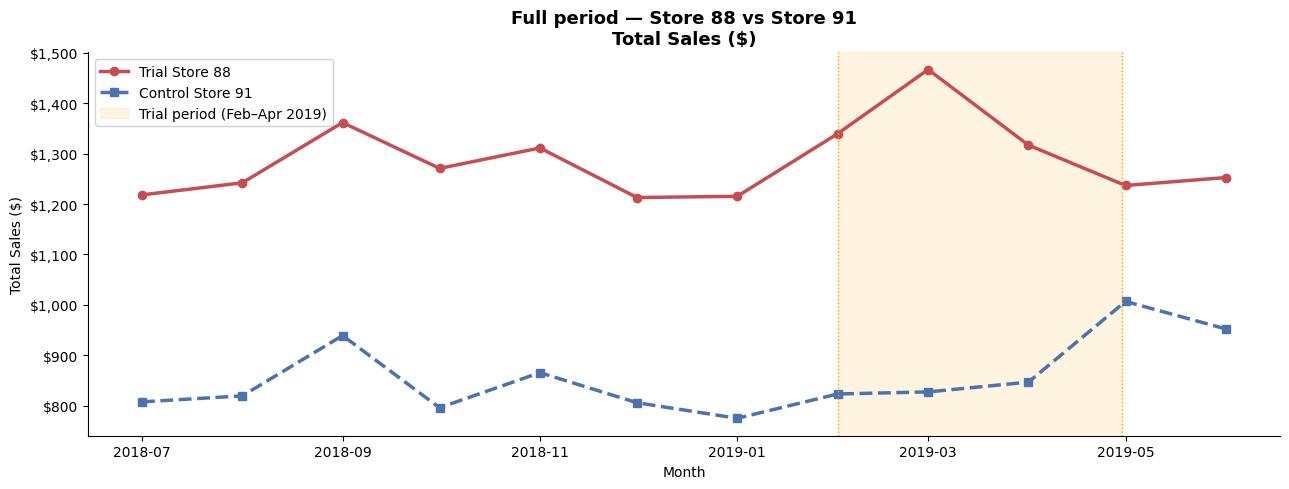

✓ Saved: fullperiod_store88_vs_91_total_sales.png


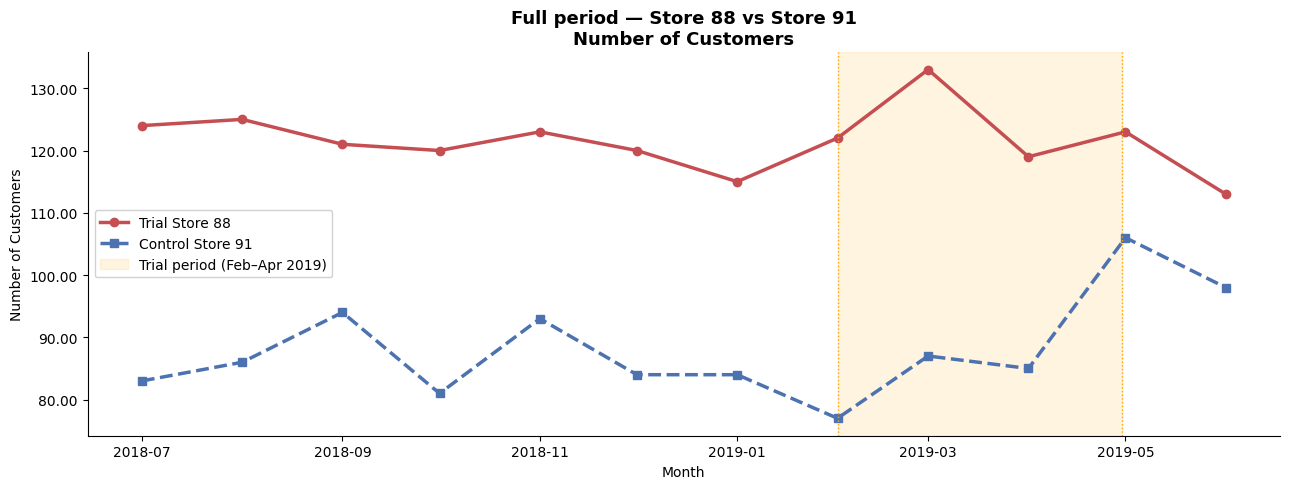

✓ Saved: fullperiod_store88_vs_91_num_customers.png


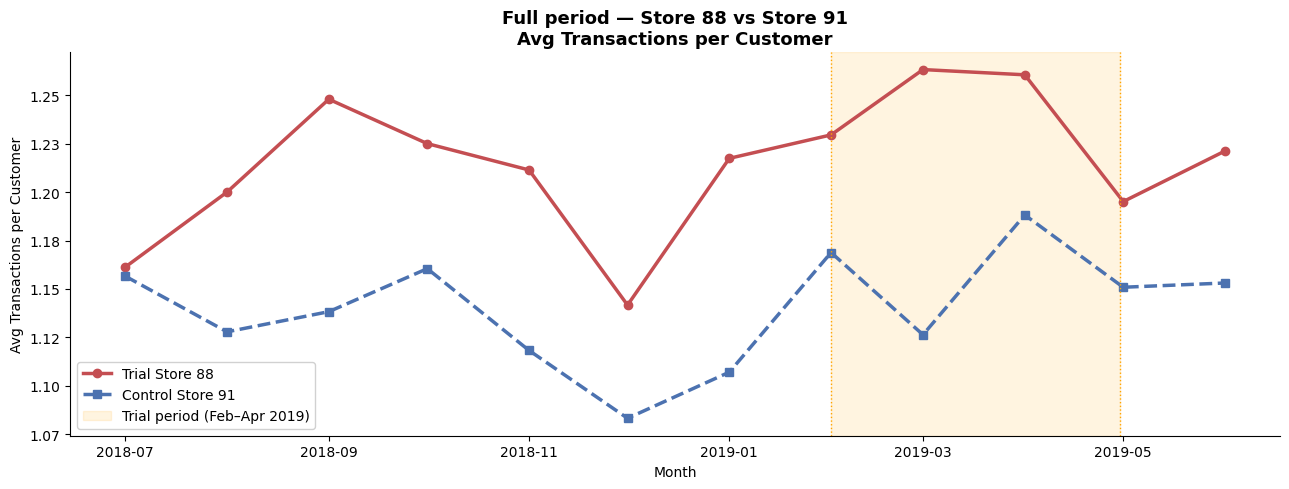

✓ Saved: fullperiod_store88_vs_91_avg_txns_per_customer.png


In [14]:
# Plot full period for all 3 pairs

for trial, control in control_map.items():
    plot_full_comparison(trial, control,
                         metric='total_sales',
                         metric_label='Total Sales ($)')
    plot_full_comparison(trial, control,
                         metric='num_customers',
                         metric_label='Number of Customers')
    plot_full_comparison(trial, control,
                         metric='avg_txns_per_customer',
                         metric_label='Avg Transactions per Customer')

In [15]:
# Statistical significance testing function
def test_trial_significance(trial_store, control_store, metric='total_sales'):
    """
    Compare trial vs control during the trial period using a t-test.
    Also calculates the percentage uplift.
    Uses pre-trial data to scale the control store to the trial store's level,
    then compares scaled control vs actual trial performance.
    """
    # Pre-trial data
    t_pre = pre_trial[pre_trial['STORE_NBR'] == trial_store][metric].values
    c_pre = pre_trial[pre_trial['STORE_NBR'] == control_store][metric].values

    # Scaling factor — adjust control to trial store's size
    min_len = min(len(t_pre), len(c_pre))
    scale   = t_pre[:min_len].mean() / c_pre[:min_len].mean() if c_pre[:min_len].mean() > 0 else 1

    # Trial period data
    t_trial = trial_period[trial_period['STORE_NBR'] == trial_store][metric].values
    c_trial = trial_period[trial_period['STORE_NBR'] == control_store][metric].values

    # Scale control to trial store's level
    c_trial_scaled = c_trial * scale

    if len(t_trial) < 2 or len(c_trial_scaled) < 2:
        print(f"  ⚠ Not enough data points for Store {trial_store}")
        return None

    # T-test
    t_stat, p_value = stats.ttest_ind(t_trial, c_trial_scaled)

    # Uplift
    trial_mean   = t_trial.mean()
    control_mean = c_trial_scaled.mean()
    uplift_pct   = ((trial_mean - control_mean) / control_mean * 100
                    if control_mean > 0 else 0)

    result = {
        'trial_store'        : trial_store,
        'control_store'      : control_store,
        'metric'             : metric,
        'trial_mean'         : round(trial_mean, 2),
        'control_mean_scaled': round(control_mean, 2),
        'uplift_pct'         : round(uplift_pct, 2),
        'scale_factor'       : round(scale, 4),
        't_statistic'        : round(t_stat, 4),
        'p_value'            : round(p_value, 4),
        'significant'        : 'Yes' if p_value < 0.05 else 'No',
    }

    return result


print("✓ Statistical significance function defined")

✓ Statistical significance function defined


In [16]:
# Run significance tests for all pairs and metrics

metrics = {
    'total_sales'          : 'Total Sales ($)',
    'num_customers'        : 'Number of Customers',
    'avg_txns_per_customer': 'Avg Transactions per Customer',
}

all_results = []

print("=" * 65)
for trial, control in control_map.items():
    print(f"\nTrial Store {trial} vs Control Store {control}")
    print("─" * 65)
    for metric, label in metrics.items():
        result = test_trial_significance(trial, control, metric)
        if result:
            all_results.append(result)
            sig = "✓ SIGNIFICANT" if result['significant'] == 'Yes' else "✗ not significant"
            print(f"  {label}")
            print(f"    Trial mean:          {result['trial_mean']:>10,.2f}")
            print(f"    Control mean (scaled):{result['control_mean_scaled']:>9,.2f}")
            print(f"    Uplift:              {result['uplift_pct']:>9.2f}%")
            print(f"    p-value:             {result['p_value']:>10.4f}  {sig}")
    print("─" * 65)

results_df = pd.DataFrame(all_results)
print("\n✓ All results stored in results_df")


Trial Store 77 vs Control Store 233
─────────────────────────────────────────────────────────────────
  Total Sales ($)
    Trial mean:              241.60
    Control mean (scaled):   189.06
    Uplift:                  27.79%
    p-value:                 0.1281  ✗ not significant
  Number of Customers
    Trial mean:               44.33
    Control mean (scaled):    35.42
    Uplift:                  25.16%
    p-value:                 0.1454  ✗ not significant
  Avg Transactions per Customer
    Trial mean:                1.04
    Control mean (scaled):     1.06
    Uplift:                  -1.82%
    p-value:                 0.6258  ✗ not significant
─────────────────────────────────────────────────────────────────

Trial Store 86 vs Control Store 155
─────────────────────────────────────────────────────────────────
  Total Sales ($)
    Trial mean:              874.07
    Control mean (scaled):   783.54
    Uplift:                  11.55%
    p-value:                 0.1275  ✗ no

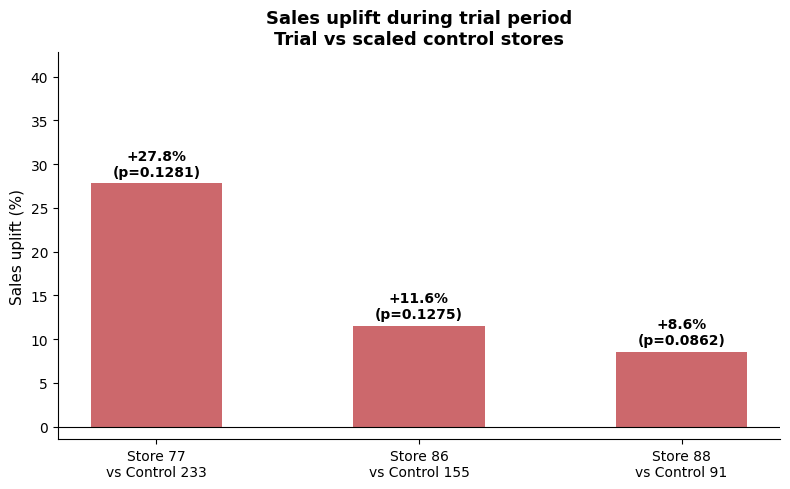

✓ Saved: uplift_summary.png


In [17]:
# Uplift summary chart


sales_results = results_df[results_df['metric'] == 'total_sales'].copy()

colors = ['#C44E52' if u > 0 else '#4C72B0'
          for u in sales_results['uplift_pct']]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [f'Store {s}\nvs Control {c}'
     for s, c in zip(sales_results['trial_store'],
                     sales_results['control_store'])],
    sales_results['uplift_pct'],
    color=colors, alpha=0.85, width=0.5
)

# Add significance labels
for bar, row in zip(bars, sales_results.itertuples()):
    label = f"{row.uplift_pct:+.1f}%\n({'p=' + str(row.p_value)})"
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5 if row.uplift_pct >= 0
            else bar.get_height() - 2,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sales uplift (%)', fontsize=11)
ax.set_title('Sales uplift during trial period\nTrial vs scaled control stores',
             fontsize=13, fontweight='bold')
ax.set_ylim(sales_results['uplift_pct'].min() - 10,
            sales_results['uplift_pct'].max() + 15)

plt.tight_layout()
plt.savefig('uplift_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: uplift_summary.png")

## Phase 3 & 4 Summary — Trial Assessment

| Trial | Control | Sales uplift | Significant? | Driver |
|---|---|---|---|---|
| 77 | 233 | +27.79% | No (p=0.13) | More customers (+25.16%) |
| 86 | 155 | +11.55% | Customers yes (p=0.01) | More customers (+12.71%) |
| 88 | 91  | +8.59%  | No (p=0.09) | Marginal across all metrics |

In [19]:
# Clean summary table — display directly without pivot
print("Complete results summary:")
display(
    results_df[['trial_store', 'control_store', 'metric',
                'trial_mean', 'control_mean_scaled',
                'uplift_pct', 'p_value', 'significant']]
    .sort_values(['trial_store', 'metric'])
    .reset_index(drop=True)
)

Complete results summary:


,trial_store,control_store,metric,trial_mean,control_mean_scaled,uplift_pct,p_value,significant
0,77,233,avg_txns_per_customer,1.04,1.06,-1.82,0.6258,No
1,77,233,num_customers,44.33,35.42,25.16,0.1454,No
2,77,233,total_sales,241.60,189.06,27.79,0.1281,No
3,86,155,avg_txns_per_customer,1.21,1.21,-0.20,0.9307,No
4,86,155,num_customers,104.00,92.28,12.71,0.0124,Yes
5,86,155,total_sales,874.07,783.54,11.55,0.1275,No
6,88,91,avg_txns_per_customer,1.25,1.24,1.17,0.5499,No
7,88,91,num_customers,124.67,116.34,7.16,0.2398,No
8,88,91,total_sales,1374.53,1265.84,8.59,0.0862,No


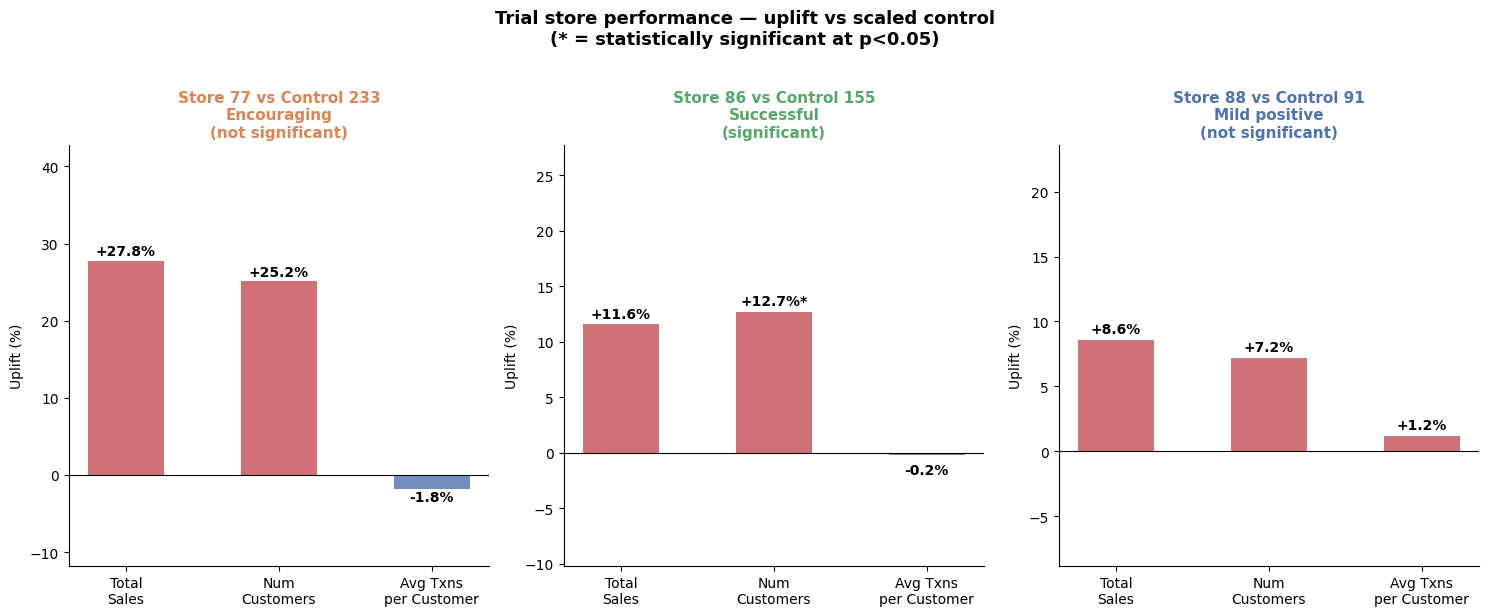

✓ Saved: final_recommendation_chart.png


In [23]:
 # Final recommendation visualisation

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

store_pairs = [(77, 233), (86, 155), (88, 91)]
verdicts    = ['Encouraging\n(not significant)',
               'Successful\n(significant)',
               'Mild positive\n(not significant)']
verdict_colors = ['#DD8452', '#55A868', '#4C72B0']

for ax, (trial, control), verdict, color in zip(
        axes, store_pairs, verdicts, verdict_colors):

    # Get metrics for this pair
    pair = results_df[results_df['trial_store'] == trial]

    metrics_plot  = ['total_sales', 'num_customers', 'avg_txns_per_customer']
    metric_labels = ['Total\nSales', 'Num\nCustomers', 'Avg Txns\nper Customer']
    uplifts       = [pair[pair['metric'] == m]['uplift_pct'].values[0]
                     for m in metrics_plot]
    pvals         = [pair[pair['metric'] == m]['p_value'].values[0]
                     for m in metrics_plot]

    bar_colors = ['#C44E52' if u > 0 else '#4C72B0' for u in uplifts]
    bars = ax.bar(metric_labels, uplifts, color=bar_colors, alpha=0.8, width=0.5)

    for bar, uplift, pval in zip(bars, uplifts, pvals):
        sig_marker = '*' if pval < 0.05 else ''
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3 if uplift >= 0 else bar.get_height() - 2,
                f'{uplift:+.1f}%{sig_marker}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Store {trial} vs Control {control}\n{verdict}',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('Uplift (%)')
    ax.set_ylim(min(uplifts) - 10, max(uplifts) + 15)

fig.suptitle('Trial store performance — uplift vs scaled control\n(* = statistically significant at p<0.05)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('final_recommendation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: final_recommendation_chart.png")

In [24]:
import os

charts = [
    f for f in os.listdir('.')
    if f.endswith('.png')
]

print("=" * 55)
print("ALL CHARTS SAVED — ready for report")
print("=" * 55)
for chart in sorted(charts):
    print(f"  {chart}")
print(f"\nTotal charts: {len(charts)}")
print("\n✓ Notebook 3 complete — export to PDF for submission")

ALL CHARTS SAVED — ready for report
  final_recommendation_chart.png
  fullperiod_store77_vs_233_avg_txns_per_customer.png
  fullperiod_store77_vs_233_num_customers.png
  fullperiod_store77_vs_233_total_sales.png
  fullperiod_store86_vs_155_avg_txns_per_customer.png
  fullperiod_store86_vs_155_num_customers.png
  fullperiod_store86_vs_155_total_sales.png
  fullperiod_store88_vs_91_avg_txns_per_customer.png
  fullperiod_store88_vs_91_num_customers.png
  fullperiod_store88_vs_91_total_sales.png
  pretrial_trend_store77_vs_233_avg_txns_per_customer.png
  pretrial_trend_store77_vs_233_num_customers.png
  pretrial_trend_store77_vs_233_total_sales.png
  pretrial_trend_store86_vs_155_avg_txns_per_customer.png
  pretrial_trend_store86_vs_155_num_customers.png
  pretrial_trend_store86_vs_155_total_sales.png
  pretrial_trend_store88_vs_91_avg_txns_per_customer.png
  pretrial_trend_store88_vs_91_num_customers.png
  pretrial_trend_store88_vs_91_total_sales.png
  uplift_summary.png

Total charts: 2

## Notebook 3 Complete

### What we did
- Loaded cleaned data from Notebook 1 (246,739 transactions)
- Calculated monthly metrics per store (sales, customers, transactions)
- Selected control stores using Pearson correlation + magnitude distance
- Visualised pre-trial and full-period trends for all 3 trial/control pairs
- Ran statistical significance testing (t-test) on all metrics
- Produced uplift analysis and written recommendation for Julia

### Control store assignments
| Trial store | Control store | Match score |
|---|---|---|
| 77 | 233 | 0.7576 |
| 86 | 155 | 0.7458 |
| 88 | 91  | 0.5010 |

### Key finding
The new chip layout drives more customers into the category.
Store 86 is the only statistically confirmed success (p=0.012).

### Next step
Task 3 — Consolidate Task 1 and Task 2 findings into a final
integrated report for Julia.

In [27]:
# Recreate segment_summary from the merged data
segment_summary = (merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        total_sales           = ('TOT_SALES',      'sum'),
        total_units           = ('PROD_QTY',       'sum'),
        num_customers         = ('LYLTY_CARD_NBR', 'nunique'),
        num_txns              = ('TXN_ID',         'nunique'),
        avg_unit_price        = ('UNIT_PRICE',     'mean'),
    )
    .reset_index()
    .round(2)
)

segment_summary['avg_spend_per_customer'] = (
    segment_summary['total_sales'] / segment_summary['num_customers']).round(2)

segment_summary['avg_txns_per_customer'] = (
    segment_summary['num_txns'] / segment_summary['num_customers']).round(2)

segment_summary['sales_pct'] = (
    segment_summary['total_sales'] / segment_summary['total_sales'].sum() * 100).round(2)

print(f"✓ segment_summary recreated — {len(segment_summary)} segments")
display(segment_summary.head())

✓ segment_summary recreated — 21 segments


,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,total_units,num_customers,num_txns,avg_unit_price,avg_spend_per_customer,avg_txns_per_customer,sales_pct
0,MIDAGE SINGLES/COUPLES,Budget,33345.70,8883,1474,4661,3.74,22.62,3.16,1.85
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,21213,3298,11034,3.99,25.69,3.35,4.69
2,MIDAGE SINGLES/COUPLES,Premium,54443.85,14400,2369,7564,3.77,22.98,3.19,3.02
3,NEW FAMILIES,Budget,20607.45,5241,1087,2813,3.92,18.96,2.59,1.14
4,NEW FAMILIES,Mainstream,15979.70,4060,830,2181,3.92,19.25,2.63,0.89


In [28]:
# Run this in Notebook 3 before closing
results_df.to_csv('quantium_trial_results.csv', index=False)
segment_summary.to_csv('quantium_segment_summary.csv', index=False)
files.download('quantium_trial_results.csv')
files.download('quantium_segment_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>